In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from astropy.table import Table
from astropy.table import vstack as tab_vstack

from lvmdap.dap_tools import list_columns,read_DAP_file,map_plot_DAP,scatter
from matplotlib import use as mpl_use
#mpl_use('Agg')

%matplotlib inline
from matplotlib import rcParams as rc
rc.update({'font.size': 19,\
           'font.weight': 900,\
           'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 19,\
           'ytick.labelsize' : 19,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mpl_colors

from my_utils import search_col

2.3.3


In [2]:
from astropy.io import fits

# Load the following FITS images from the directory hips
fits_files = [
	"hips/cutout-CDS_P_WISE_W4.fits",
	"hips/cutout-CDS_P_WISE_W3.fits",
	"hips/cutout-CDS_P_WISE_W2.fits"
]

# Open the FITS files
fits_data = [fits.open(file) for file in fits_files]

In [3]:
#sec_sky = fits_data[0][0].data[125:175,850:950]

/tmp/ipykernel_37773/3422757629.py:17: RuntimeWarning: invalid value encountered in sqrt
  processed_images = [processed_images[i]**gamma_correction[i] for i in range(3)]
/tmp/ipykernel_37773/3422757629.py:17: RuntimeWarning: invalid value encountered in power
  processed_images = [processed_images[i]**gamma_correction[i] for i in range(3)]
/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


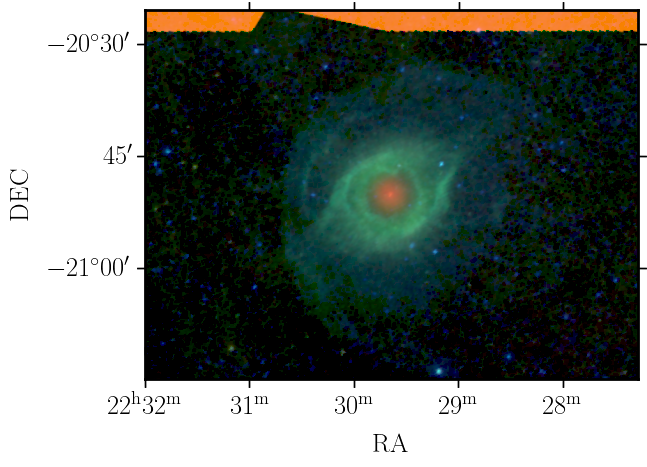

In [4]:
from astropy.visualization import simple_norm
from astropy.wcs import WCS

# Define gamma correction and scaling factors for each channel
gamma_correction = [0.5, 0.4, 0.2]  # Gamma for W2, W3, W4
scaling_factors = [1.0, 1.0, 1.0]   # Scaling for W2, W3, W4

# Extract the image data and WCS from the FITS files
image_data = [fits_data[i][0].data for i in range(3)]
sky_data = [fits_data[i][0].data[125:175,850:950] for i in range(3)]
# Subtract sky background
processed_images = [image_data[i] - np.median(sky_data[i]) for i in range(3)]

wcs = WCS(fits_data[0][0].header)

# Apply gamma cocutout-CDS_P_GALEXGR6_7_FUV.fitsnge(3)  to each channel
processed_images = [processed_images[i]**gamma_correction[i] for i in range(3)]
#]

# Normalize each channel to [0, 1]
normalized_images = [
    scaling_factors[i]*simple_norm(processed_images[i], 'linear')(processed_images[i])
    for i in range(3)
]

# Stack the images into an RGB array
rgb_image = np.stack(normalized_images, axis=-1)
#rgb_image[1,:,:] =



# Plot the RGB image with WCS
fig, ax = plt.subplots(subplot_kw={'projection': wcs})
ax.imshow(rgb_image, origin='lower')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
plt.show()

In [5]:
DIR_DAP = 'output_dap'
#dap_file='Helix_DR19.dap.fits.gz'
dap_file='Helix_DR19_new.dap.fits.gz'

dap_file=f'{DIR_DAP}/{dap_file}'
hdu_list = fits.open(dap_file)
hdu_list.info()

Filename: output_dap/Helix_DR19_new.dap.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     899   ()      
  1  PT            1 BinTableHDU     21   1754R x 6C   [9A, D, D, L, K, K]   
  2  RSP           1 BinTableHDU    101   1754R x 31C   [9A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  3  COEFFS        1 BinTableHDU     35   189432R x 13C   [9A, K, K, D, D, D, D, D, D, D, D, D, D]   
  4  PM_ELINES     1 BinTableHDU     29   26310R x 10C   [9A, K, 10A, D, D, D, D, D, D, D]   
  5  NP_ELINES_B    1 BinTableHDU   1835   1754R x 913C   [9A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 

In [6]:
tab_PT = Table(hdu_list[1].data)
tab_PT

id,ra,dec,mask,fiberid,exposure
str9,float64,float64,bool,int64,int64
4297.3,337.4169474614286,-21.084344018449997,True,3,4297
4297.4,337.42638153117906,-21.07898431939437,True,4,4297
4297.5,337.43581492731073,-21.073624095271583,True,5,4297
4297.6,337.4452142099591,-21.068264089182854,True,6,4297
4297.7,337.45464625878174,-21.062902818356775,True,7,4297
4297.8,337.46407763267024,-21.05754102404877,True,8,4297
4297.9,337.47350833118605,-21.0521787067879,True,9,4297
4297.10,337.48293835389075,-21.0468158671032,True,10,4297
4297.11,337.49233426716734,-21.04145325730424,True,11,4297


Trimming to pixels: x [245, 954], y [95, 804]
337.41060585298, -20.837152011780006
600.0, 449.9999999999962
(709, 709)


/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
/home/sanchez/miniconda3/envs/lvmdap/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


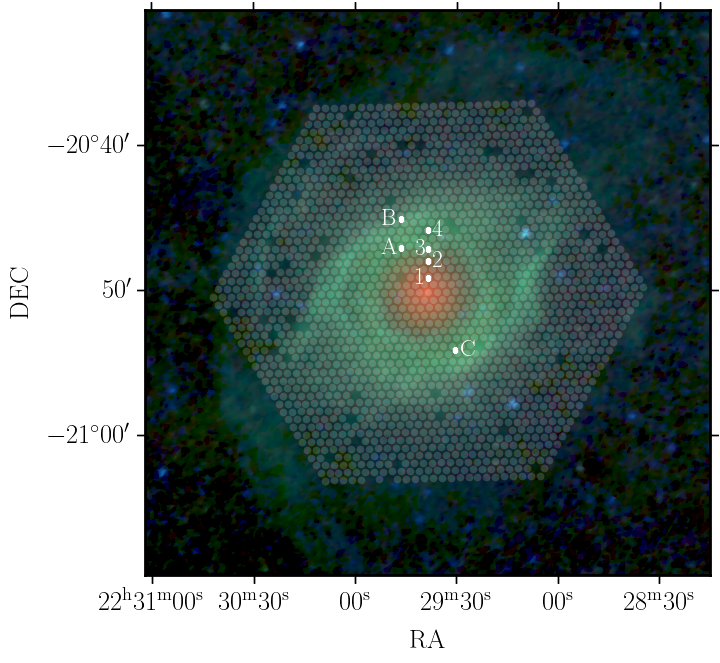

In [10]:
# Calculate the pixel range for 1 degree along each axis
deg_to_pix_x = abs(1 / wcs.wcs.cdelt[0])  # Convert 1 degree to pixels using CDELT for x-axis
deg_to_pix_y = abs(1 / wcs.wcs.cdelt[1])  # Convert 1 degree to pixels using CDELT for y-axis

center_pix = rgb_image.shape[1] // 2, rgb_image.shape[0] // 2
center_RA, center_DEC = wcs.wcs_pix2world(center_pix[0], center_pix[1], 1)
center_x, center_y = wcs.wcs_world2pix(center_RA, center_DEC, 1)


sc = 0.65
# Define the pixel range for trimming
x_min = int(center_x - sc*deg_to_pix_x / 2)
x_max = int(center_x + sc*deg_to_pix_x / 2)
y_min = int(center_y - sc*deg_to_pix_y / 2)
y_max = int(center_y + sc*deg_to_pix_y / 2)

print(f"Trimming to pixels: x [{x_min}, {x_max}], y [{y_min}, {y_max}]")
print(f"{center_RA}, {center_DEC}")
print(f"{center_x}, {center_y}")    
# Trim the RGB image
trimmed_rgb_image = rgb_image[y_min:y_max, x_min:x_max]
center_pix = trimmed_rgb_image.shape[1] // 2, trimmed_rgb_image.shape[0] // 2

wcs_trimmed = wcs.slice((slice(y_min, y_max), slice(x_min, x_max)))

# Plot the trimmed RGB image with WCS
fig, ax = plt.subplots(subplot_kw={'projection': wcs_trimmed},figsize=(8,7))
ax.imshow(trimmed_rgb_image, origin='lower')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')

#x_lim = ax.get_xlim()
#print(x_lim)
#y_lim = ax.get_ylim()
#print(y_lim)

PT_pix = wcs_trimmed.wcs_world2pix(tab_PT['ra'], tab_PT['dec'], 1)
#PT_pix[0] = PT_pix[0] - x_min
#PT_pix[1] = PT_pix[1] - y_min

ax.scatter(PT_pix[1],PT_pix[0],s=30,edgecolor='red',facecolor='white',lw=0.5,marker='o',alpha=0.17)

masked_img = trimmed_rgb_image[:,:,0].copy()
print(masked_img.shape)
masked_img.fill(0)

LVM_fib = 17.5
#print(wcs_trimmed.celt[0])
for xy in zip(PT_pix[1],PT_pix[0]):
    r_fib = np.abs((LVM_fib/3600)/wcs_trimmed.wcs.cdelt[0]) # in pixels    
    for i in range(int(xy[1]-r_fib),int(xy[1]+r_fib)+1):
        for j in range(int(xy[0]-r_fib),int(xy[0]+r_fib)+1):
            if (i - xy[1])**2 + (j - xy[0])**2 <= r_fib**2:
                masked_img[i,j] = 1
#    print(xy[0],xy[1])


# Henry et al. 1999  
RA_C = center_RA - 2/60
DEC_C = center_DEC - 4/60
X_C, Y_C = wcs_trimmed.wcs_world2pix(RA_C, DEC_C, 1)
ax.scatter(X_C, Y_C, s=5, marker='s', color='white')
ax.text(X_C+7, Y_C,'C',color='white',fontsize=17,fontweight='bold',ha='left',va='center')
RA_B = center_RA + 2/60
DEC_B = center_DEC + 5/60
X_B, Y_B = wcs_trimmed.wcs_world2pix(RA_B, DEC_B, 1)
ax.scatter(X_B, Y_B, s=5, marker='s', color='white')
ax.text(X_B-5, Y_B,'B',color='white',fontsize=17,fontweight='bold',ha='right',va='center')
RA_A = center_RA + 2/60
DEC_A = center_DEC + 3/60
X_A, Y_A = wcs_trimmed.wcs_world2pix(RA_A, DEC_A, 1)
ax.scatter(X_A, Y_A, s=5, marker='s', color='white')
ax.text(X_A-5, Y_A,'A',color='white',fontsize=17,fontweight='bold',ha='right',va='center')

# O'dell 1998

RA_1 = center_RA #+ 2/60
DEC_1 = center_DEC + 58.3/3600
X_1, Y_1 = wcs_trimmed.wcs_world2pix(RA_1, DEC_1, 1)
ax.scatter(X_1, Y_1, s=5, marker='s', color='white')
ax.text(X_1-2, Y_1,'1',color='white',fontsize=17,fontweight='bold',ha='right',va='center')

#RA_1 = center_RA #+ 2/60
#DEC_1 = center_DEC - 58.3/3600
#X_1, Y_1 = wcs_trimmed.wcs_world2pix(RA_1, DEC_1, 1)
#ax.scatter(X_1, Y_1, s=5, marker='s', color='white')
#ax.text(X_1-3, Y_1,'1',color='white',fontsize=17,fontweight='bold',ha='right',va='center')

RA_2 = center_RA #+ 2/60
DEC_2 = center_DEC + 127/3600
X_2, Y_2 = wcs_trimmed.wcs_world2pix(RA_2, DEC_2, 1)
ax.scatter(X_2, Y_2, s=5, marker='s', color='white')
ax.text(X_2+5, Y_2,'2',color='white',fontsize=17,fontweight='bold',ha='left',va='center')

RA_3 = center_RA #+ 2/60
DEC_3 = center_DEC + 179/3600
X_3, Y_3 = wcs_trimmed.wcs_world2pix(RA_3, DEC_3, 1)
ax.scatter(X_3, Y_3, s=5, marker='s', color='white')
ax.text(X_3-3, Y_3,'3',color='white',fontsize=17,fontweight='bold',ha='right',va='center')

RA_4 = center_RA #+ 2/60
DEC_4 = center_DEC + 255/3600
X_4, Y_4 = wcs_trimmed.wcs_world2pix(RA_4, DEC_4, 1)
ax.scatter(X_4, Y_4, s=5, marker='s', color='white')
ax.text(X_4+5, Y_4,'4',color='white',fontsize=17,fontweight='bold',ha='left',va='center')

#center_x, center_y = wcs.wcs_world2pix(center_RA, center_DEC, 1)


#ax.imshow(masked_img, origin='lower', cmap='Reds', alpha=0.3)

#ax.scatter(PT_pix[1],PT_pix[0],s=30,edgecolor='white',facecolor='none',lw=0.5,marker='o',alpha=0.15)
#ax.scatter(center_pix[0],center_pix[1],s=500,edgecolor='red',facecolor='none',lw=2,marker='o')
#plt.show()
fig.tight_layout()
fig.savefig('figs/Helix_WISE.pdf', transparent=False, facecolor='white', edgecolor='white')

In [251]:
#print(r_fib)
size = (x_max-x_min)*wcs.wcs.cdelt[0]
print(size)

-0.6499366299762375


In [252]:
#
# Aperture corrections!
#
trim_proc_images = [image_data[i][y_min:y_max, x_min:x_max] - np.median(sky_data[i]) for i in range(3)]
for i in range(3):
    W_all = np.sum(trim_proc_images[i])
    W_LVM = np.sum(trim_proc_images[i][masked_img==1])
    print(i,W_all,W_LVM,W_LVM/W_all)




0 45061.18 35537.992 0.78866094
1 1599348.6 1106139.0 0.69161844
2 324780.72 222264.53 0.6843526


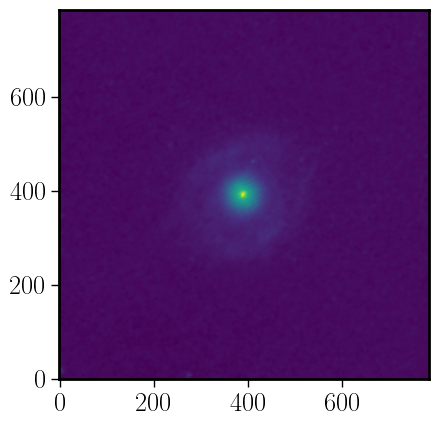

In [202]:
plt.imshow(trim_proc_images[0],origin='lower')

In [160]:
#plt.imshow(trim_proc_images[1],origin='lower')